STARTING ROBUST STAT-ARB ENGINE (NOISE-FILTERED OVERRIDE)
[Pipeline Info] 'SPY' ticker detected. Using real SPY price series for CAPM benchmark.
[DAG Pre-Compute] Initializing Vectorized Matrix Space...
[DAG Pre-Compute] Processing 1570 Sector-Matched Residual Pairs...
[DAG Pre-Compute] Completed successfully. Executing Portfolio Routing Loop.
[Friction Engine] Goldilocks absolute minimum alpha floor calibrated to 0.66%

[Dynamic Rebalance @ 2024-09-09 | Progress:   0.2% (1/500)] Cause: INITIAL_ENTRY
  --> Pipeline Funnel : Ghost=4 | Promoted=0 | Live=0
------------------------------------------------------------

[Dynamic Rebalance @ 2024-09-26 | Progress:   2.8% (14/500)] Cause: SIGNAL_ENTRY
  --> Pipeline Funnel : Ghost=4 | Promoted=1 | Live=1
  --> SLSQP Metrics   : Eff Gross=0.37 | Port Vol=0.0611 | SPY Overlay=20.0%
  --> Top Allocations :
      [BASE] AVGO/SMCI | W_A: -16.7% | W_B: 6.6% | Inno Z: 1.23 | ECDF: 0.97 | Alpha: 2.1921
-------------------------------------------------

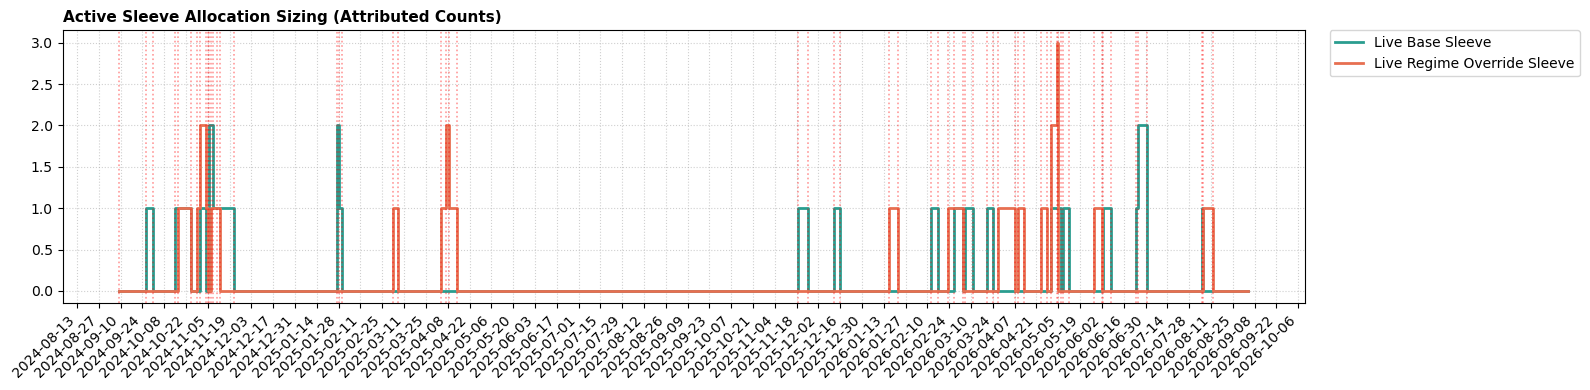

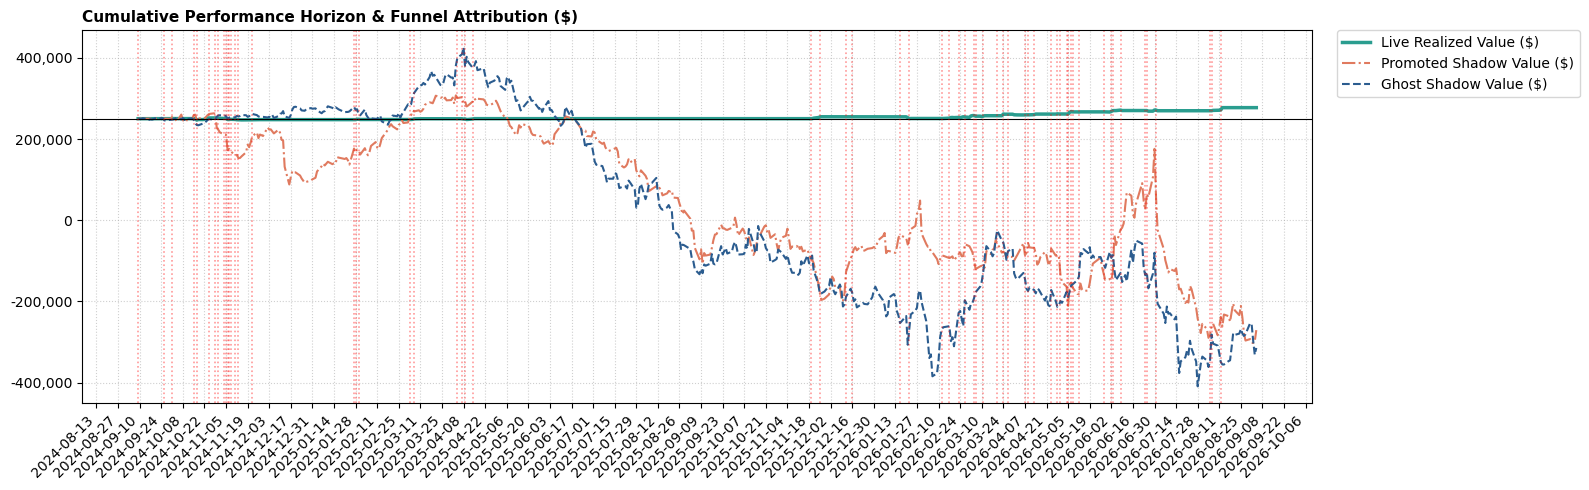

In [ ]:
# ==============================================================================
# S&P 500 STAT-ARB ENGINE: REGIME OVERRIDE WITH NOISE-FILTERED EDGE
# ==============================================================================
import os
import gc
import pickle
import warnings
from typing import Dict, List, Tuple, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
from scipy.optimize import minimize as scipy_minimize
import vectorbt as vbt
from joblib import Parallel, delayed
from datetime import datetime

warnings.filterwarnings("ignore")
pd.set_option('display.max_rows', 250)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_id = "model_A_filtered_override"

# ==============================================================================
# 1. INSTITUTIONAL PARAMETER CONFIGURATION
# ==============================================================================
run_params = {
    "price_csv": "data/universe_daily_train.csv",
    "oos_price_csv": "data/universe_daily_val.csv",
    "constituents_path": "data/constituents.csv",
    "state_persistence_file": f"artifacts/{model_id}/stat_arb_state_{timestamp}.pkl",

    "lookback_days": 504,             
    "min_history_days": 100,          
    "weight_drift_threshold": 0.04,     
    "screening_freq_days": 20,          
    "quarantine_days": 30,             
    
    "kalman_delta": 1e-4,              
    "kalman_obs_noise": 1e-3,          
    "max_hurst_exponent": 0.43,        
    "max_slope_tstat": 1.96,           
    
    "min_correlation": 0.45,           
    "p_value_threshold": 0.04,         
    
    "min_half_life": 1.5,             
    "max_half_life": 25.0,            
    "tau_hl_penalty": 5.0,             
    
    # [CORRECTED] NON-PARAMETRIC SIGNAL & NOISE FILTERS
    "entry_ecdf_percentile": 0.90,         # Top 10% decile for low-vol tracking
    "min_override_z": 0.60,                # Absolute floor to prevent trading pure noise (Z=0.24)
    "friction_clearance_multiplier": 15.0, # Demands 15x physical friction to cover stochastic market impact
    
    "exit_z_spread": 0.20,             
    "stop_loss_z": 2.20,               
    "min_holding_days": 2,             
    "max_holding_days": 12,            
    
    "promote_top_n": 30,               
    "ghost_truncation_quantile": 0.20, 
    
    # DYNAMIC SLEEVE SCALING & OVERLAY SAFEGUARDS
    "low_density_threshold": 3,        
    "max_sleeve_weight_low_density": 0.35, 
    "max_sleeve_weight": 0.20,         
    "max_single_stock_gross": 0.15,    
    "max_pair_spy_beta": 1.20,         
    "max_spy_overlay_weight": 0.20,    
    
    "max_net_dollar_exposure": 0.02,   
    "max_net_beta_exposure": 0.0100,   
    "max_sector_exposure": 0.05,       
    "max_gross_exposure": 1.80,        

    "max_adv_participation": 0.015,    
    "initial_capital": 250_000.0,
    "exec_fee": 0.00015,              
    "borrow_bps": 50.0
}

# ==============================================================================
# 2. STATE PERSISTENCE ENGINE
# ==============================================================================
class StatePersistenceEngine:
    @staticmethod
    def save_checkpoint(filepath: str, state_dict: dict):
        try:
            os.makedirs(os.path.dirname(filepath), exist_ok=True)
            with open(filepath, "wb") as f:
                pickle.dump(state_dict, f)
        except Exception: pass

    @staticmethod
    def load_checkpoint(filepath: str) -> Optional[dict]:
        if not os.path.exists(filepath): return None
        try:
            with open(filepath, "rb") as f: return pickle.load(f)
        except Exception: return None

# ==============================================================================
# 3. VECTORIZED MATH KERNELS & STATISTICAL UTILITIES
# ==============================================================================
def compute_sortino_ratio(returns: pd.Series, target_return: float = 0.0) -> float:
    if len(returns) < 5 or returns.std() < 1e-8: return 0.0
    downside_returns = returns[returns < target_return]
    if len(downside_returns) < 2: return 0.0
    downside_std = np.sqrt(np.mean(downside_returns**2)) * np.sqrt(252.0)
    return float((returns.mean() * 252.0) / max(downside_std, 1e-6))

def rolling_ecdf_fast(arr: np.ndarray, window: int = 63) -> np.ndarray:
    n = len(arr)
    out = np.zeros(n)
    for i in range(n):
        start = max(0, i - window + 1)
        out[i] = np.sum(arr[start:i+1] <= arr[i]) / (i - start + 1)
    return out

def get_rolling_half_life(spread: pd.Series, window: int = 126) -> pd.Series:
    s_lag = spread.shift(1)
    s_diff = spread.diff()
    var_x = s_lag.rolling(window).var()
    cov_xy = s_lag.rolling(window).cov(s_diff)
    gamma = cov_xy / np.maximum(var_x, 1e-8)
    gamma = np.clip(gamma, -0.9999, -1e-5)
    hl = -np.log(2.0) / np.log(1.0 + gamma)
    return hl

def get_rolling_hurst(spread: pd.Series, window: int = 126, max_lag: int = 20) -> pd.Series:
    lags = np.arange(2, max_lag)
    log_lags = np.log(lags)
    tau_dict = {lag: spread.diff(lag).rolling(window).std() for lag in lags}
    tau_df = pd.DataFrame(tau_dict)
    log_tau = np.log(np.maximum(tau_df, 1e-8))
    mean_x, var_x = np.mean(log_lags), np.var(log_lags)
    mean_y = log_tau.mean(axis=1)
    cov_xy = ((log_tau.subtract(mean_y, axis=0)) * (log_lags - mean_x)).mean(axis=1)
    return (cov_xy / var_x) * 2.0

def batch_kalman_filter_numpy(y: np.ndarray, x: np.ndarray, delta: float, obs_noise: float):
    N = len(y)
    betas, intercepts, innovations, F_arr = np.zeros(N), np.zeros(N), np.zeros(N), np.zeros(N)
    state_mean, state_cov = np.zeros(2), np.eye(2)
    Q = (delta / (1.0 - delta)) * np.eye(2)
    for t in range(N):
        H = np.array([1.0, x[t]])
        pred_cov = state_cov + Q
        v = y[t] - np.dot(H, state_mean)
        F = np.dot(H, np.dot(pred_cov, H)) + obs_noise
        K = np.dot(pred_cov, H) / F
        state_mean += K * v
        state_cov = pred_cov - np.outer(K, np.dot(H, pred_cov))
        intercepts[t], betas[t], innovations[t], F_arr[t] = state_mean[0], state_mean[1], v, F
    return betas, intercepts, innovations, F_arr

def compute_in_sample_residualization(dag_df: pd.DataFrame, spy_series: pd.Series, lookback_days: int) -> pd.DataFrame:
    train_dag = dag_df.iloc[:lookback_days]
    train_spy = spy_series.iloc[:lookback_days]
    X_train = np.column_stack([np.ones(len(train_spy)), np.log(train_spy.values)])
    X_inv = np.linalg.pinv(X_train.T @ X_train) @ X_train.T
    Y_train_log = np.log(train_dag.values)
    betas_fitted = X_inv @ Y_train_log
    X_full = np.column_stack([np.ones(len(spy_series)), np.log(spy_series.values)])
    Y_full_log = np.log(dag_df.values)
    Y_res_full = Y_full_log - (X_full @ betas_fitted)
    return pd.DataFrame(Y_res_full, index=dag_df.index, columns=dag_df.columns)

def process_pair_history_fast(t1: str, t2: str, p1_arr: np.ndarray, p2_arr: np.ndarray, m_ret_arr: np.ndarray, dates_idx: pd.DatetimeIndex, params: dict):
    y, x = np.log(p1_arr), np.log(p2_arr)
    betas, intercepts, innovations, F_arr = batch_kalman_filter_numpy(y, x, delta=params['kalman_delta'], obs_noise=params['kalman_obs_noise'])
    F_series = pd.Series(F_arr, index=dates_idx).rolling(21, min_periods=5).mean().bfill().values
    spread_vol = np.sqrt(np.maximum(F_series, 1e-4))
    z_spread = np.clip(innovations / spread_vol, -5.0, 5.0)
    
    ecdf_ranks = rolling_ecdf_fast(np.abs(innovations), window=63)
    
    spread = pd.Series(y - betas * x, index=dates_idx)
    hl = get_rolling_half_life(spread).fillna(20.0).clip(params['min_half_life'], params['max_half_life'])
    hurst = get_rolling_hurst(spread).fillna(0.50)
    W_slope = 20
    t_idx = pd.Series(np.arange(len(spread)), index=dates_idx)
    var_t = float((W_slope**2 - 1.0) / 12.0)
    slope_s = spread.rolling(W_slope).cov(t_idx) / var_t
    var_s = spread.rolling(W_slope).var()
    se_slope = np.sqrt(np.maximum(1e-8, var_s - (slope_s**2 * var_t)) / ((W_slope - 2.0) * var_t))
    slope_tstats = (slope_s / np.maximum(se_slope, 1e-6)).fillna(0.0).values

    ret_A = pd.Series(p1_arr, index=dates_idx).pct_change().fillna(0.0)
    ret_B = pd.Series(p2_arr, index=dates_idx).pct_change().fillna(0.0)
    m_ret = pd.Series(m_ret_arr, index=dates_idx).fillna(0.0)
    var_m = m_ret.ewm(span=30).var().fillna(1e-4)
    cov_a_m = ret_A.ewm(span=30).cov(m_ret).fillna(0.0)
    cov_b_m = ret_B.ewm(span=30).cov(m_ret).fillna(0.0)
    beta_a_spy = (cov_a_m / np.maximum(var_m, 1e-6)).values
    beta_b_spy = (cov_b_m / np.maximum(var_m, 1e-6)).values
    pair_spy_betas = beta_a_spy - (betas * beta_b_spy)
    
    exp_yield = np.maximum(0.0, np.abs(z_spread) - params['exit_z_spread']) * spread_vol
    alpha = exp_yield * (252.0 / hl.values) * (1.0 - np.exp(-hl.values / params['tau_hl_penalty']))
    pair_returns = (ret_A.values - betas * ret_B.values) / (1.0 + np.abs(betas))
    
    return (t1, t2), pd.DataFrame({
        'Beta': betas, 'Intercept': intercepts, 'SPY_Beta': pair_spy_betas,
        'Slope_TStat': slope_tstats, 'Z_Spread': z_spread, 'ECDF_Rank': ecdf_ranks,
        'Spread_Vol': spread_vol, 'Half_Life': hl.values, 'Hurst': hurst.values, 
        'Parametric_Alpha': alpha, 'Spread_Return': pair_returns
    }, index=dates_idx)

class UniverseScreener:
    def __init__(self, constituents_path: str):
        self.constituents_path = constituents_path
    def get_sectors(self, tickers: List[str]) -> pd.Series:
        if os.path.exists(self.constituents_path):
            const = pd.read_csv(self.constituents_path)
            sym_col = "Symbol" if "Symbol" in const.columns else "Ticker"
            return pd.Series(tickers, index=tickers).map(dict(zip(const[sym_col], const["GICS Sector"]))).fillna("Unknown")
        return pd.Series("Unknown", index=tickers)

# ==============================================================================
# 4. SLSQP OPTIMIZER WITH DYNAMIC SLEEVE SCALING
# ==============================================================================
class ConvexPortfolioOptimizer:
    def __init__(self, params: dict):
        self.params = params

    @staticmethod
    def calculate_max_weight_drift(current_sleeve_weights: Dict[Tuple[str, str], float], target_sleeve_weights: Dict[Tuple[str, str], float]) -> float:
        all_keys = set(current_sleeve_weights.keys()).union(target_sleeve_weights.keys())
        if not all_keys: return 0.0
        return float(max([abs(current_sleeve_weights.get(pk, 0.0) - target_sleeve_weights.get(pk, 0.0)) for pk in all_keys]))

    def allocate(self, live_df: pd.DataFrame, sectors: pd.Series, current_weights: dict, alpha_cube: dict, current_idx: int):
        if live_df.empty: return {}, {}, {}, 0.0
        N = len(live_df)
        pair_keys = [(r["Asset_A"], r["Asset_B"]) for _, r in live_df.iterrows()]
        
        returns_list = []
        for pk in pair_keys:
            s_ret = alpha_cube[pk]["Spread_Return"].iloc[max(0, current_idx-63):current_idx].values
            if len(s_ret) < 63: s_ret = np.pad(s_ret, (63 - len(s_ret), 0), 'constant')
            returns_list.append(s_ret)
            
        returns_mat = np.column_stack(returns_list)
        cov_matrix = np.cov(returns_mat, rowvar=False) * 252.0
        if N == 1: cov_matrix = np.array([[cov_matrix]])
        cov_matrix += np.eye(N) * 1e-5 

        pair_betas, pair_spy_betas, pair_zs, alphas = live_df["Beta"].values, live_df["SPY_Beta"].values, live_df["Z_Spread"].values, live_df["Parametric_Alpha"].values
        w_prev_pairs = np.array([current_weights.get(pk, 0.0) for pk in pair_keys])
        turnover_bps = (self.params["exec_fee"] * 2.0) + 0.0005 

        dollar_mults = np.where(pair_zs > 0, pair_betas - 1.0, 1.0 - pair_betas)
        spy_beta_mults = np.where(pair_zs > 0, -pair_spy_betas, pair_spy_betas)

        max_pair_beta = float(self.params.get("max_pair_spy_beta", 1.20))
        spy_beta_mults_clipped = np.clip(spy_beta_mults, -max_pair_beta, max_pair_beta)

        pair_secs = np.array([sectors.get(live_df.iloc[i]["Asset_A"], "Unknown") for i in range(N)])
        unique_secs = np.unique(pair_secs)

        def objective(w):
            risk = np.dot(w.T, np.dot(cov_matrix, w))
            turnover = np.sum(np.abs(w - w_prev_pairs)) * turnover_bps
            return risk + turnover

        low_density_threshold = int(self.params.get("low_density_threshold", 3))
        if N < low_density_threshold:
            max_sleeve_limit = float(self.params.get("max_sleeve_weight_low_density", 0.35))
            max_stock_cap = max_sleeve_limit
        else:
            max_sleeve_limit = float(self.params.get("max_sleeve_weight", 0.20))
            max_stock_cap = float(self.params.get("max_single_stock_gross", 0.15))

        dynamic_sleeve_cap = min(max_sleeve_limit, self.params["max_gross_exposure"] / max(1, N))
        target_gross = min(self.params["max_gross_exposure"], N * dynamic_sleeve_cap)
        min_gross = max(0.30, target_gross * 0.5) 
        
        constraints = [
            {'type': 'ineq', 'fun': lambda w: target_gross - np.sum(w)}, 
            {'type': 'ineq', 'fun': lambda w: np.sum(w) - min_gross},    
            {'type': 'ineq', 'fun': lambda w: self.params["max_net_dollar_exposure"] - np.abs(np.sum(w * dollar_mults))}
        ]
        for s in unique_secs:
            constraints.append({'type': 'ineq', 'fun': lambda w, sec=s: self.params["max_sector_exposure"] - np.abs(np.sum(w[pair_secs == sec] * dollar_mults[pair_secs == sec]))})

        all_assets = list(set(live_df["Asset_A"]).union(live_df["Asset_B"]))
        for asset in all_assets:
            asset_mask = np.zeros(N)
            for i, r in live_df.iterrows():
                idx_pos = live_df.index.get_loc(i)
                if r["Asset_A"] == asset: asset_mask[idx_pos] += 1.0
                if r["Asset_B"] == asset: asset_mask[idx_pos] += abs(r["Beta"])
            constraints.append({'type': 'ineq', 'fun': lambda w, mask=asset_mask: max_stock_cap - np.sum(w * mask)})

        alpha_median = max(float(np.median(alphas)), 1e-6)
        bounds = []
        for i in range(N):
            if alphas[i] <= 1e-6: bounds.append((0.0, 0.0))
            else: bounds.append((0.0, dynamic_sleeve_cap * np.clip(float(alphas[i]) / alpha_median, 0.20, 1.00)))

        init_w = (1.0 / np.maximum(live_df["Spread_Vol"].values, 1e-4))
        init_w = np.minimum((init_w / np.sum(init_w)) * target_gross, [b[1] for b in bounds])

        res = scipy_minimize(objective, init_w, method='SLSQP', bounds=bounds, constraints=constraints)
        best_w = res.x if res.success else init_w
        best_w[best_w < 0.01] = 0.0

        max_overlay_cap = float(self.params.get("max_spy_overlay_weight", 0.20))
        net_pair_spy_beta = np.sum(best_w * spy_beta_mults_clipped)
        
        required_spy_hedge = -net_pair_spy_beta
        if abs(required_spy_hedge) > max_overlay_cap:
            scale_down_factor = max_overlay_cap / abs(required_spy_hedge)
            best_w *= scale_down_factor
            w_spy_overlay = np.sign(required_spy_hedge) * max_overlay_cap
        else:
            w_spy_overlay = required_spy_hedge

        allocs, memory = {}, {}
        for i, pk in enumerate(pair_keys):
            if best_w[i] > 0:
                row = live_df.iloc[i]
                w_a = -best_w[i] if row["Z_Spread"] > 0 else best_w[i]
                w_b = best_w[i] * row["Beta"] if row["Z_Spread"] > 0 else -best_w[i] * row["Beta"]
                allocs[pk] = {row["Asset_A"]: w_a, row["Asset_B"]: w_b, "Sleeve_Weight": best_w[i]}
                memory[pk] = {
                    "Beta_Entry": row["Beta"], 
                    "Intercept_Entry": row["Intercept_Entry"] if row["Is_Active"] else row["Intercept"],
                    "Spread_Vol_Entry": row["Spread_Vol_Entry"] if row["Is_Active"] else row["Spread_Vol"],
                    "Entry_Z": row["Entry_Z"] if row["Is_Active"] else row["Z_Spread"],
                    "Parametric_Alpha": row["Parametric_Alpha"], 
                    "Days_Held": row.get("Days_Held", 0),
                    "Entry_Type": row.get("Entry_Type", "BASE")
                }

        metrics = {
            "Portfolio_Variance": np.dot(best_w.T, np.dot(cov_matrix, best_w)), 
            "Turnover_Cost": np.sum(np.abs(best_w - w_prev_pairs)) * turnover_bps, 
            "Effective_Gross": np.sum(best_w) + abs(w_spy_overlay)
        }
        return allocs, memory, metrics, w_spy_overlay

# ==============================================================================
# 5. UNIFIED ORCHESTRATOR PIPELINE
# ==============================================================================
def run_unified_pipeline(params: dict):
    print("=" * 85, flush=True)
    print("STARTING ROBUST STAT-ARB ENGINE (NOISE-FILTERED OVERRIDE)", flush=True)
    print("=" * 85, flush=True)
    
    try:
        prices_train = pd.read_csv(params["price_csv"], index_col=0, parse_dates=True)
        prices_val = pd.read_csv(params["oos_price_csv"], index_col=0, parse_dates=True)
        prices_full = pd.concat([prices_train, prices_val]).dropna(axis=1, how="all").ffill()
    except Exception:
        prices_train = pd.read_csv(params["price_csv"], index_col=0, parse_dates=True)
        prices_full = prices_train.ffill()

    prices_full = prices_full[~prices_full.index.duplicated()].sort_index().ffill()

    try:
        open_train = pd.read_csv(params["price_csv"].replace("close", "open"), index_col=0, parse_dates=True)
        open_val = pd.read_csv(params["oos_price_csv"].replace("close", "open"), index_col=0, parse_dates=True)
        open_full = pd.concat([open_train, open_val]).dropna(axis=1, how="all").ffill()
        open_full = open_full[~open_full.index.duplicated(keep='first')].sort_index()
    except FileNotFoundError:
        open_full = prices_full.copy()

    if 'SPY' in prices_full.columns:
        print("[Pipeline Info] 'SPY' ticker detected. Using real SPY price series for CAPM benchmark.", flush=True)
        market_ret = prices_full['SPY'].pct_change().fillna(0.0)
        tradeable_prices = prices_full.drop(columns=['SPY'])
    else:
        print("[Pipeline Info] 'SPY' ticker not detected. Using synthetic equal-weighted index.", flush=True)
        tradeable_prices = prices_full
        market_ret = tradeable_prices.pct_change().mean(axis=1)

    print("[DAG Pre-Compute] Initializing Vectorized Matrix Space...", flush=True)
    dag_df = tradeable_prices.dropna(axis=1)
    valid_tickers = dag_df.columns
    start_idx = min(params["lookback_days"], len(prices_train))

    screener = UniverseScreener(params["constituents_path"])
    sectors = screener.get_sectors(valid_tickers.tolist())

    spy_series = prices_full['SPY'] if 'SPY' in prices_full.columns else dag_df.mean(axis=1)
    res_dag_df = compute_in_sample_residualization(dag_df, spy_series, start_idx)

    in_sample_res = res_dag_df.iloc[:start_idx]
    corr_matrix = np.corrcoef(np.diff(in_sample_res.values, axis=0), rowvar=False)
    sector_arr = sectors.reindex(valid_tickers).values
    sec_match = sector_arr[:, None] == sector_arr[None, :]
    mask = np.triu(sec_match & (corr_matrix >= params["min_correlation"]), k=1)
    
    candidate_pairs = [(valid_tickers[i], valid_tickers[j]) for i, j in zip(*np.where(mask))]
    print(f"[DAG Pre-Compute] Processing {len(candidate_pairs)} Sector-Matched Residual Pairs...", flush=True)
    
    dates_idx = dag_df.index
    market_ret_arr = market_ret.values
    col_map = {col: idx for idx, col in enumerate(dag_df.columns)}
    dag_values = dag_df.values

    with Parallel(n_jobs=-1, backend="loky") as parallel:
        results = parallel(
            delayed(process_pair_history_fast)(
                t1, t2, dag_values[:, col_map[t1]], dag_values[:, col_map[t2]], 
                market_ret_arr, dates_idx, params
            ) for t1, t2 in candidate_pairs
        )
    
    alpha_cube = {pair: df for pair, df in results}
    print("[DAG Pre-Compute] Completed successfully. Executing Portfolio Routing Loop.", flush=True)
    
    engine_alloc = ConvexPortfolioOptimizer(params)
    
    state = StatePersistenceEngine.load_checkpoint(params["state_persistence_file"]) or {}
    active_pairs, cooldown_tracker = state.get("active_pairs", {}), state.get("cooldown_tracker", {})
    total_steps = len(prices_full) - start_idx

    master_weights = pd.DataFrame(np.nan, index=prices_full.index, columns=prices_full.columns, dtype=np.float64)
    ghost_weights = pd.DataFrame(np.nan, index=prices_full.index, columns=tradeable_prices.columns, dtype=np.float64)
    promoted_weights = pd.DataFrame(np.nan, index=prices_full.index, columns=tradeable_prices.columns, dtype=np.float64)
    
    pair_weight_matrices, current_sleeve_weights, target_sleeve_weights = {}, {}, {}
    metrics_history, cached_keys = [], []
    trade_entry_log = {}
    days_since_screening = 0

    execution_bps = params["exec_fee"] * 2.0 * 10000.0 
    borrow_bps_10d = params["borrow_bps"] * (10.0 / 365.0)
    physical_friction_annualized = (execution_bps + borrow_bps_10d) / 100.0 
    adaptive_min_alpha = physical_friction_annualized * params.get("friction_clearance_multiplier", 15.0)
    print(f"[Friction Engine] Goldilocks absolute minimum alpha floor calibrated to {adaptive_min_alpha:.2f}%", flush=True)

    for i in range(start_idx, len(prices_full)):
        current_date = prices_full.index[i]
        step_num = i - start_idx + 1
        progress_pct = (step_num / total_steps) * 100.0

        has_exit = False
        for p in list(active_pairs.keys()):
            mem = active_pairs[p]
            current_state = alpha_cube[p].iloc[i]
            mem.update({"Days_Held": mem["Days_Held"] + 1})

            log_a_cur, log_b_cur = np.log(prices_full.at[current_date, p[0]]), np.log(prices_full.at[current_date, p[1]])
            spread_mtm = log_a_cur - (mem["Beta_Entry"] * log_b_cur)
            e_t_frozen = (spread_mtm - mem["Intercept_Entry"]) / max(mem["Spread_Vol_Entry"], 1e-4)

            exp_yield_frozen = max(0.0, abs(e_t_frozen) - params['exit_z_spread']) * mem["Spread_Vol_Entry"]
            frozen_alpha = exp_yield_frozen * (252.0 / current_state["Half_Life"]) * (1.0 - np.exp(-current_state["Half_Life"] / params['tau_hl_penalty']))
            mem["Parametric_Alpha"] = frozen_alpha

            max_allowed_days = min(params["max_holding_days"], int(current_state["Half_Life"] * 1.25))
            is_alpha_stale = (mem["Days_Held"] >= 8) and (mem["Parametric_Alpha"] < 0.35)

            should_close = (
                abs(e_t_frozen) >= params["stop_loss_z"] or
                (mem["Days_Held"] >= params["min_holding_days"] and (
                    abs(e_t_frozen) <= params["exit_z_spread"] or 
                    mem["Days_Held"] >= max_allowed_days or 
                    is_alpha_stale
                ))
            )

            if should_close:
                has_exit = True
                master_weights.loc[current_date, p[0]], master_weights.loc[current_date, p[1]] = 0.0, 0.0
                if p in pair_weight_matrices:
                    pair_weight_matrices[p].loc[current_date, p[0]], pair_weight_matrices[p].loc[current_date, p[1]] = 0.0, 0.0

                if abs(e_t_frozen) >= params["stop_loss_z"]: cooldown_tracker[p] = params["quarantine_days"]
                del active_pairs[p]
                if p in current_sleeve_weights: del current_sleeve_weights[p]

        if not active_pairs:
            current_sleeve_weights, target_sleeve_weights = {}, {}

        for p in list(cooldown_tracker.keys()):
            cooldown_tracker[p] -= 1
            if cooldown_tracker[p] <= 0: del cooldown_tracker[p]

        if days_since_screening >= params["screening_freq_days"] or not cached_keys:
            lb_prices = res_dag_df.iloc[i - params["lookback_days"] : i]
            def _check_coint(t1, t2):
                p1, p2 = lb_prices[t1].values, lb_prices[t2].values
                if coint(p1, p2)[1] <= params["p_value_threshold"]: return (t1, t2)
                return None
            cached_keys = [res for res in [_check_coint(p[0], p[1]) for p in candidate_pairs] if res is not None]
            days_since_screening = 0
        days_since_screening += 1

        ghost_records = []
        for p in list(active_pairs.keys()) + [k for k in cached_keys if k not in active_pairs and k not in cooldown_tracker]:
            if p not in alpha_cube: continue
            state_t = alpha_cube[p].iloc[i]
            if state_t.isna().any(): continue
            
            is_active = p in active_pairs
            if not is_active and state_t["Hurst"] >= params["max_hurst_exponent"]: continue
            if not is_active and state_t["Half_Life"] == params["max_half_life"]: continue
            if not is_active and abs(state_t["Slope_TStat"]) >= params.get("max_slope_tstat", 1.96): continue
            
            rec = {
                "Asset_A": p[0], "Asset_B": p[1], "Beta": state_t["Beta"], "SPY_Beta": state_t["SPY_Beta"],
                "Intercept": state_t["Intercept"], "Half_Life_Days": state_t["Half_Life"], 
                "Z_Spread": active_pairs[p]["Entry_Z"] if is_active else state_t["Z_Spread"],
                "ECDF_Rank": state_t["ECDF_Rank"],
                "Parametric_Alpha": active_pairs[p]["Parametric_Alpha"] if is_active else state_t["Parametric_Alpha"], 
                "Spread_Vol": state_t["Spread_Vol"], 
                "Days_Held": active_pairs[p]["Days_Held"] if is_active else 0,
                "Is_Active": is_active, 
                "Entry_Type": active_pairs[p].get("Entry_Type", "BASE") if is_active else "PENDING",
                "Beta_Entry": active_pairs[p]["Beta_Entry"] if is_active else state_t["Beta"],
                "Intercept_Entry": active_pairs[p]["Intercept_Entry"] if is_active else state_t["Intercept"],
                "Spread_Vol_Entry": active_pairs[p]["Spread_Vol_Entry"] if is_active else state_t["Spread_Vol"],
                "Entry_Z": active_pairs[p]["Entry_Z"] if is_active else state_t["Z_Spread"]
            }
            ghost_records.append(rec)
            
        ghost_df = pd.DataFrame(ghost_records)
        promoted_ghosts = pd.DataFrame()

        if not ghost_df.empty:
            ghost_pool = ghost_df[~ghost_df["Is_Active"]].copy()
            if not ghost_pool.empty:
                # Require absolute minimum Z and adaptive alpha floor to prevent trading pure noise
                eligible_entries = ghost_pool[
                    (ghost_pool["ECDF_Rank"] >= params["entry_ecdf_percentile"]) & 
                    (ghost_pool["Parametric_Alpha"] >= adaptive_min_alpha) &
                    (abs(ghost_pool["Z_Spread"]) >= params["min_override_z"])
                ]
                
                if not eligible_entries.empty:
                    min_score = max(1e-6, eligible_entries["Parametric_Alpha"].quantile(params["ghost_truncation_quantile"]))
                    promoted_ghosts = eligible_entries[eligible_entries["Parametric_Alpha"] >= min_score].sort_values("Parametric_Alpha", ascending=False).head(params["promote_top_n"])
                    # Tag entry types
                    promoted_ghosts["Entry_Type"] = np.where(abs(promoted_ghosts["Z_Spread"]) >= params.get("entry_z_base", 0.95), "BASE", "OVERRIDE")

            if len(ghost_pool) > 0:
                g_alloc = 1.0 / len(ghost_pool)
                for _, r in ghost_pool.iterrows():
                    ghost_weights.loc[current_date, r["Asset_A"]] = -g_alloc if r["Z_Spread"] > 0 else g_alloc
                    ghost_weights.loc[current_date, r["Asset_B"]] = g_alloc * r["Beta"] if r["Z_Spread"] > 0 else -g_alloc * r["Beta"]
            
            if len(promoted_ghosts) > 0:
                p_alloc = 1.0 / len(promoted_ghosts)
                for _, r in promoted_ghosts.iterrows():
                    promoted_weights.loc[current_date, r["Asset_A"]] = -p_alloc if r["Z_Spread"] > 0 else p_alloc
                    promoted_weights.loc[current_date, r["Asset_B"]] = p_alloc * r["Beta"] if r["Z_Spread"] > 0 else -p_alloc * r["Beta"]

        current_max_drift = ConvexPortfolioOptimizer.calculate_max_weight_drift(current_sleeve_weights, target_sleeve_weights)
        should_rebalance = has_exit or len(promoted_ghosts) > 0 or current_max_drift >= params["weight_drift_threshold"] or (i == start_idx)

        if should_rebalance:
            trigger_cause = (
                "INITIAL_ENTRY" if (i == start_idx) else
                ("SIGNAL_EXIT" if has_exit else
                ("SIGNAL_ENTRY" if not promoted_ghosts.empty else f"WEIGHT_DRIFT ({current_max_drift:.1%})"))
            )

            print(f"\n[Dynamic Rebalance @ {current_date.date()} | Progress: {progress_pct:5.1f}% ({step_num}/{total_steps})] Cause: {trigger_cause}", flush=True)

            if ghost_df.empty:
                metrics_history.append({"Date": current_date, "Ghost_Size": 0, "Promoted_Size": 0, "Live_Size": len(active_pairs), "Live_Base": 0, "Live_Override": 0, "Opt_Exp_Variance": 0.0, "Effective_Gross": 0.0, "Mean_Innovation_Z": 0.0, "Mean_Parametric_Alpha": 0.0, "rebalanced": 1})
                continue

            live_candidates = ghost_df[ghost_df["Is_Active"]]
            live_df = pd.concat([live_candidates, promoted_ghosts]).drop_duplicates(subset=["Asset_A", "Asset_B"])
            
            allocs, active_pairs_updates, opt, w_spy_overlay = engine_alloc.allocate(live_df, sectors, current_sleeve_weights, alpha_cube, i)
            
            dropped = set(active_pairs.keys()) - set(allocs.keys())
            for p in dropped:
                master_weights.loc[current_date, p[0]], master_weights.loc[current_date, p[1]] = 0.0, 0.0
                if p in pair_weight_matrices:
                    pair_weight_matrices[p].loc[current_date, p[0]], pair_weight_matrices[p].loc[current_date, p[1]] = 0.0, 0.0
                cooldown_tracker[p] = params["quarantine_days"]

            active_pairs = active_pairs_updates
            current_sleeve_weights = {p: w["Sleeve_Weight"] for p, w in allocs.items()}
            current_sleeve_weights["SPY_OVERLAY"] = w_spy_overlay
            target_sleeve_weights = current_sleeve_weights.copy()

            if 'SPY' in master_weights.columns:
                master_weights.loc[current_date, 'SPY'] = w_spy_overlay

            for p, w in allocs.items():
                if p not in pair_weight_matrices: pair_weight_matrices[p] = pd.DataFrame(np.nan, index=prices_full.index, columns=[p[0], p[1]])
                pair_weight_matrices[p].loc[current_date, p[0]] = w[p[0]]
                pair_weight_matrices[p].loc[current_date, p[1]] = w[p[1]]
                
                curr_w_a = master_weights.at[current_date, p[0]]
                curr_w_b = master_weights.at[current_date, p[1]]
                master_weights.at[current_date, p[0]] = (0.0 if np.isnan(curr_w_a) else curr_w_a) + w[p[0]]
                master_weights.at[current_date, p[1]] = (0.0 if np.isnan(curr_w_b) else curr_w_b) + w[p[1]]
                
                trade_entry_log[p] = active_pairs[p].get("Entry_Type", "BASE")

            avg_inno_z = np.mean([abs(mem['Entry_Z']) for mem in active_pairs.values()]) if active_pairs else 0.0
            avg_alpha = live_df["Parametric_Alpha"].mean() if not live_df.empty else 0.0
            
            base_count = sum(1 for v in active_pairs.values() if v.get("Entry_Type") == "BASE")
            over_count = sum(1 for v in active_pairs.values() if v.get("Entry_Type") == "OVERRIDE")
            
            metrics_history.append({"Date": current_date, "Ghost_Size": len(ghost_pool) if 'ghost_pool' in locals() else 0, "Promoted_Size": len(promoted_ghosts), "Live_Size": len(active_pairs), "Live_Base": base_count, "Live_Override": over_count, "Opt_Exp_Variance": opt.get("Portfolio_Variance", 0.0), "Effective_Gross": opt.get("Effective_Gross", 0.0), "Mean_Innovation_Z": avg_inno_z, "Mean_Parametric_Alpha": avg_alpha, "rebalanced": 1})

            print(f"  --> Pipeline Funnel : Ghost={len(ghost_pool) if 'ghost_pool' in locals() else 0} | Promoted={len(promoted_ghosts)} | Live={len(active_pairs)}", flush=True)
            if active_pairs:
                print(f"  --> SLSQP Metrics   : Eff Gross={opt.get('Effective_Gross', 0):.2f} | Port Vol={np.sqrt(max(0, opt.get('Portfolio_Variance', 0))):.4f} | SPY Overlay={w_spy_overlay:.1%}", flush=True)
                print(f"  --> Top Allocations :", flush=True)
                sorted_allocs = sorted(active_pairs.keys(), key=lambda x: abs(allocs[x]['Sleeve_Weight']), reverse=True)[:3]
                for p in sorted_allocs:
                    w_data = allocs[p]
                    mem = active_pairs[p]
                    ecdf_val = live_df[(live_df["Asset_A"]==p[0]) & (live_df["Asset_B"]==p[1])]["ECDF_Rank"].values[0] if not live_df[(live_df["Asset_A"]==p[0]) & (live_df["Asset_B"]==p[1])].empty else 1.0
                    print(f"      [{mem.get('Entry_Type', 'BASE')}] {p[0]}/{p[1]} | W_A: {w_data[p[0]]:.1%} | W_B: {w_data[p[1]]:.1%} | Inno Z: {mem['Entry_Z']:.2f} | ECDF: {ecdf_val:.2f} | Alpha: {mem['Parametric_Alpha']:.4f}", flush=True)
            print("-" * 60, flush=True)

            StatePersistenceEngine.save_checkpoint(params["state_persistence_file"], {"active_pairs": active_pairs, "cooldown_tracker": cooldown_tracker})

    cap = params["max_gross_exposure"]
    for df_w in [master_weights, ghost_weights, promoted_weights]:
        abs_sum = df_w.abs().sum(axis=1)
        exceed_mask = abs_sum > cap
        if exceed_mask.any(): df_w.loc[exceed_mask] = df_w.loc[exceed_mask].div(abs_sum[exceed_mask], axis=0) * cap

    exec_weights = master_weights.shift(1).iloc[start_idx:]
    exec_ghost_weights = ghost_weights.shift(1).iloc[start_idx:]
    exec_promoted_weights = promoted_weights.shift(1).iloc[start_idx:]

    for p in pair_weight_matrices: pair_weight_matrices[p] = pair_weight_matrices[p].ffill().fillna(0.0).shift(1)

    rebalance_metrics_df = pd.DataFrame(metrics_history).set_index("Date")
    exec_close_prices, exec_open_prices = prices_full[master_weights.columns].iloc[start_idx:], open_full[prices_full.columns].iloc[start_idx:]

    metrics_df = pd.DataFrame(index=exec_close_prices.index).join(rebalance_metrics_df, how="left")
    metrics_df["rebalanced"] = metrics_df["rebalanced"].fillna(0).astype(int)
    for col in ["Ghost_Size", "Promoted_Size", "Live_Size", "Live_Base", "Live_Override", "Opt_Exp_Variance", "Effective_Gross", "Mean_Innovation_Z", "Mean_Parametric_Alpha"]:
        if col in metrics_df.columns:
            metrics_df[col] = metrics_df[col].ffill().fillna(0.0)

    global_engine = VectorbtBacktestEngine(params)
    net_portfolio_live, val_live, true_gross_exp_series = global_engine.run_backtest(exec_close_prices, exec_open_prices, exec_weights)
    _, val_ghost, _ = global_engine.run_backtest(exec_close_prices[tradeable_prices.columns], exec_open_prices[tradeable_prices.columns], exec_ghost_weights)
    _, val_promoted, _ = global_engine.run_backtest(exec_close_prices[tradeable_prices.columns], exec_open_prices[tradeable_prices.columns], exec_promoted_weights)

    ret_live, ret_ghost, ret_promoted = val_live.pct_change().fillna(0.0), val_ghost.pct_change().fillna(0.0), val_promoted.pct_change().fillna(0.0)
    metrics_df["Live_Realized_Return"], metrics_df["Ghost_Realized_Return"], metrics_df["Promoted_Realized_Return"] = ret_live, ret_ghost, ret_promoted

    ann_factor = 252.0 / max(1, len(ret_live))
    ann_ret_ghost = (((1.0 + ((val_ghost.iloc[-1] / params["initial_capital"]) - 1.0)) ** ann_factor) - 1.0) * 100.0
    ann_ret_promoted = (((1.0 + ((val_promoted.iloc[-1] / params["initial_capital"]) - 1.0)) ** ann_factor) - 1.0) * 100.0
    ann_ret_live = (((1.0 + ((val_live.iloc[-1] / params["initial_capital"]) - 1.0)) ** ann_factor) - 1.0) * 100.0

    sortino_ghost, sortino_promoted, sortino_live = compute_sortino_ratio(ret_ghost), compute_sortino_ratio(ret_promoted), compute_sortino_ratio(ret_live)
    neutrality_metrics_df, verdict = MarketNeutralityDiagnosticEngine(max_beta=params["max_net_beta_exposure"], max_r2=0.005).analyze(strategy_returns=ret_live, benchmark_returns=market_ret.iloc[start_idx:])
    
    committee_report = CommitteeTearsheetEngine(params).generate_tearsheets(tradeable_prices, pair_weight_matrices, trade_entry_log)

    stats_df = net_portfolio_live.stats()
    stats_df["Max Gross Exposure [%]"] = float(true_gross_exp_series.max() * 100.0)

    moo_blotter = LiveMOOOrderGenerator(min_order_usd=500.0, max_adv_part=params.get("max_adv_participation", 0.015)).generate_blotter(
        target_weights=master_weights.ffill().fillna(0.0).iloc[-1], current_positions={}, latest_prices=prices_full.iloc[-1],
        rolling_adv_shares=(prices_full.iloc[-20:].mean() * 50_000).fillna(1_000_000), portfolio_nav=params["initial_capital"]
    )

    return committee_report, net_portfolio_live, metrics_df, moo_blotter, {
        "stats_df": stats_df, "ann_ret_ghost": ann_ret_ghost, "sortino_ghost": sortino_ghost,
        "ann_ret_promoted": ann_ret_promoted, "sortino_promoted": sortino_promoted,
        "ann_ret_live": ann_ret_live, "sortino_live": sortino_live,
        "ret_delta_parametric": ann_ret_promoted - ann_ret_ghost, "sortino_delta_parametric": sortino_promoted - sortino_ghost,
        "ret_delta_optimizer": ann_ret_live - ann_ret_promoted, "sortino_delta_optimizer": sortino_live - sortino_promoted,
        "verdict": verdict, "neutrality_metrics_df": neutrality_metrics_df
    }

class CommitteeTearsheetEngine:
    def __init__(self, params: dict):
        self.init_cap, self.fee, self.borrow = params.get("initial_capital", 250_000.0), params.get("exec_fee", 0.00015), (params.get("borrow_bps", 50.0) / 10000.0) / 252.0

    def generate_tearsheets(self, prices_df: pd.DataFrame, pair_weight_matrices: dict, trade_entry_log: dict) -> pd.DataFrame:
        results = []
        for pair_key, w_df in pair_weight_matrices.items():
            a, b = pair_key
            active_dates = w_df.dropna(how='all').index
            if len(active_dates) == 0: continue
            start_date = active_dates[0]
            p_oos = prices_df[[a, b]].loc[start_date:]
            w_target = w_df.loc[start_date:].copy()
            w_target.iloc[-1] = 0.0 
            
            pf_gross = vbt.Portfolio.from_orders(close=p_oos, size=w_target, size_type='targetpercent', group_by=True, cash_sharing=True, init_cash=self.init_cap, fees=self.fee)
            asset_values = pf_gross.asset_value(group_by=False)
            net_val = pf_gross.value() - (asset_values.where(asset_values < 0, 0).abs().sum(axis=1) * self.borrow).cumsum()
            net_ret = net_val.pct_change().fillna(0)
            
            mean_ret, std_ret = net_ret.mean(), net_ret.std()
            down_std = np.sqrt((net_ret[net_ret < 0] ** 2).mean())
            trades = pf_gross.trades.count()
            
            results.append({
                "Strategy_Origin": trade_entry_log.get(pair_key, "UNKNOWN"),
                "Pair_Legs": f"{a} / {b}", "Total_Return_[%]": ((net_val.iloc[-1] / self.init_cap) - 1.0) * 100,
                "Sharpe_Ratio": (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else 0.0,
                "Sortino_Ratio": (mean_ret / down_std) * np.sqrt(252) if down_std > 0 else 0.0,
                "Max_DD_[%]": ((1 - net_val / net_val.cummax()).max() if not net_val.empty else 0.0) * 100,
                "Win_Rate_[%]": ((pf_gross.trades.winning.count() / trades) * 100) if trades > 0 else 0.0, "Total_Trades": trades
            })
            del pf_gross
            gc.collect()

        return pd.DataFrame(results).sort_values(["Strategy_Origin", "Sharpe_Ratio"], ascending=[True, False]).reset_index(drop=True) if results else pd.DataFrame()

class VectorbtBacktestEngine:
    def __init__(self, params: dict):
        self.initial_capital, self.exec_fee, self.daily_borrow_rate = params.get("initial_capital", 250_000.0), params.get("exec_fee", 0.00015), (params.get("borrow_bps", 50.0) / 10000.0) / 252.0

    def run_backtest(self, close_prices_df: pd.DataFrame, open_prices_df: pd.DataFrame, weights_df: pd.DataFrame) -> Tuple[vbt.Portfolio, pd.Series, pd.Series]:
        tradable_assets = weights_df.columns.intersection(close_prices_df.columns)
        p_close_oos, p_open_oos, sparse_weights = close_prices_df[tradable_assets].ffill(), open_prices_df[tradable_assets].ffill(), weights_df[tradable_assets]

        pf_gross = vbt.Portfolio.from_orders(close=p_close_oos, price=p_open_oos, size=sparse_weights, size_type='targetpercent', group_by=True, cash_sharing=True, init_cash=self.initial_capital, fees=self.exec_fee)
        asset_values = pf_gross.asset_value(group_by=False)
        net_portfolio_value = pf_gross.value() - (asset_values.where(asset_values < 0, 0).abs().sum(axis=1) * self.daily_borrow_rate).cumsum()
        true_gross_exposure = (asset_values.abs().sum(axis=1) / net_portfolio_value.replace(0.0, np.nan)).fillna(0.0)
        return pf_gross, net_portfolio_value, true_gross_exposure

class MarketNeutralityDiagnosticEngine:
    def __init__(self, max_beta: float = 0.0100, max_r2: float = 0.005):
        self.max_beta, self.max_r2 = max_beta, max_r2

    def analyze(self, strategy_returns: pd.Series, benchmark_returns: pd.Series) -> Tuple[pd.DataFrame, dict]:
        aligned_df = pd.concat([strategy_returns, benchmark_returns], axis=1).dropna()
        aligned_df.columns = ["Strategy", "Benchmark"]
        r_p, r_m = aligned_df["Strategy"], aligned_df["Benchmark"]
        
        capm_model = sm.OLS(r_p, sm.add_constant(r_m)).fit()
        alpha_ann, beta_m, p_val_beta, t_stat_beta, r2_capm = capm_model.params.get("const", 0.0) * 252.0, capm_model.params.get("Benchmark", 0.0), capm_model.pvalues.get("Benchmark", 1.0), capm_model.tvalues.get("Benchmark", 0.0), capm_model.rsquared

        bull_mask, bear_mask = r_m > 0, r_m < 0
        beta_bull = sm.OLS(r_p[bull_mask], sm.add_constant(r_m[bull_mask])).fit().params.get("Benchmark", 0.0) if bull_mask.sum() > 10 else 0.0
        beta_bear = sm.OLS(r_p[bear_mask], sm.add_constant(r_m[bear_mask])).fit().params.get("Benchmark", 0.0) if bear_mask.sum() > 10 else 0.0

        metrics = [
            {"Metric": "Annualized Alpha", "Value": f"{alpha_ann:.2%}", "Threshold": "N/A", "Status": "INFO"},
            {"Metric": "Market Beta (β_m)", "Value": f"{beta_m:.4f}", "Threshold": f"< |{self.max_beta}|", "Status": "PASS" if abs(beta_m) <= self.max_beta else "FAIL"},
            {"Metric": "Beta p-value", "Value": f"{p_val_beta:.4f}", "Threshold": ">= 0.05", "Status": "PASS" if p_val_beta >= 0.05 else "FAIL"},
            {"Metric": "Beta t-statistic", "Value": f"{t_stat_beta:.4f}", "Threshold": "< |1.96|", "Status": "PASS" if abs(t_stat_beta) < 1.96 else "FAIL"},
            {"Metric": "Variance Explained (R²)", "Value": f"{r2_capm:.2%}", "Threshold": f"< {self.max_r2:.1%}", "Status": "PASS" if r2_capm <= self.max_r2 else "FAIL"},
            {"Metric": "Bull Market Beta (R_m > 0)", "Value": f"{beta_bull:.4f}", "Threshold": f"< |{self.max_beta}|", "Status": "PASS" if abs(beta_bull) <= self.max_beta else "FAIL"},
            {"Metric": "Bear Market Beta (R_m < 0)", "Value": f"{beta_bear:.4f}", "Threshold": f"< |{self.max_beta}|", "Status": "PASS" if abs(beta_bear) <= self.max_beta else "FAIL"}
        ]
        metrics_df = pd.DataFrame(metrics)
        return metrics_df, {"Market_Neutral": "TRUE" if (metrics_df["Status"] != "FAIL").all() else "FALSE", "Core_Failure_Reason": "None" if (metrics_df["Status"] != "FAIL").all() else ", ".join(metrics_df[metrics_df["Status"] == "FAIL"]["Metric"].tolist())}

class LiveMOOOrderGenerator:
    def __init__(self, min_order_usd: float = 250.0, max_adv_part: float = 0.015, round_lots: bool = False):
        self.min_order_usd, self.max_adv_part, self.round_lots = min_order_usd, max_adv_part, round_lots

    def generate_blotter(self, target_weights: pd.Series, current_positions: Dict[str, int], latest_prices: pd.Series, rolling_adv_shares: pd.Series, portfolio_nav: float) -> pd.DataFrame:
        blotter = []
        for ticker in set(target_weights.index).union(current_positions.keys()):
            t_weight, price, adv_shares = float(target_weights.get(ticker, 0.0)), float(latest_prices.get(ticker, np.nan)), float(rolling_adv_shares.get(ticker, 1_000_000.0))
            if np.isnan(price) or price <= 0: continue

            curr_shares = int(current_positions.get(ticker, 0))
            raw_target_shares = int((t_weight * portfolio_nav) / price)
            max_allowed_delta = int(adv_shares * self.max_adv_part)
            desired_delta = raw_target_shares - curr_shares
            
            target_shares = curr_shares + (max_allowed_delta if desired_delta > max_allowed_delta else (-max_allowed_delta if desired_delta < -max_allowed_delta else desired_delta))
            if self.round_lots: target_shares = (target_shares // 100) * 100

            delta_shares = target_shares - curr_shares
            delta_value = delta_shares * price

            if abs(delta_value) >= self.min_order_usd and delta_shares != 0:
                blotter.append({
                    "Ticker": ticker, "Action": "BUY" if delta_shares > 0 else "SELL", "Order_Type": "MOO",
                    "Delta_Shares": abs(delta_shares), "Target_Shares": target_shares, "Current_Shares": curr_shares,
                    "Est_Order_USD": round(abs(delta_value), 2), "Target_Weight_%": round((target_shares * price / portfolio_nav) * 100, 2),
                    "ADV_Participation_%": round((abs(delta_shares) / max(1.0, adv_shares)) * 100, 3), "Price_Ref": round(price, 2)
                })

        return pd.DataFrame(blotter).sort_values("Est_Order_USD", ascending=False).reset_index(drop=True) if blotter else pd.DataFrame(columns=["Ticker", "Action", "Order_Type", "Delta_Shares", "Target_Shares", "Current_Shares", "Est_Order_USD", "Target_Weight_%", "ADV_Participation_%", "Price_Ref"])

def _get_next_run_dir(base_dir: str = "results") -> str:
    os.makedirs(base_dir, exist_ok=True)
    existing_ids = [int(d) for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and d.isdigit()]
    run_dir = os.path.join(base_dir, str(max(existing_ids) + 1 if existing_ids else 1))
    os.makedirs(run_dir, exist_ok=True)
    return run_dir

def format_independent_axis(ax, rebalance_dates):
    for r_date in rebalance_dates: ax.axvline(x=r_date, color="red", linestyle=":", alpha=0.4, linewidth=1.2)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

def print_execution_summary(metrics_df, stats_df, committee_report, moo_blotter, ann_ret_ghost, sortino_ghost, ann_ret_promoted, sortino_promoted, ann_ret_live, sortino_live, ret_delta_parametric, sortino_delta_parametric, ret_delta_optimizer, sortino_delta_optimizer, verdict, neutrality_metrics_df):
    print("\n" + "=" * 85, flush=True)
    print("FUNNEL CONVERSION ATTRIBUTION & MARGINAL PERFORMANCE REPORT", flush=True)
    print("=" * 85, flush=True)
    print(f"  {'Funnel Tier / Portfolio Stage':<38} | {'Ann. Return [%]':<18} | {'Sortino Ratio':<18}", flush=True)
    print("-" * 85, flush=True)
    print(f"  {'Ghost Portfolio (Raw Universe)':<38} | {ann_ret_ghost:17.2f}% | {sortino_ghost:18.4f}", flush=True)
    print(f"  {'Promoted Portfolio (Parametric Gated)':<38} | {ann_ret_promoted:17.2f}% | {sortino_promoted:18.4f}", flush=True)
    print(f"  {'Live Portfolio (SLSQP Optimized)':<38} | {ann_ret_live:17.2f}% | {sortino_live:18.4f}", flush=True)
    print("-" * 85, flush=True)
    print(f"  {'--> Parametric Selection Delta':<38} | {ret_delta_parametric:+17.2f}% | {sortino_delta_parametric:+18.4f}", flush=True)
    print(f"  {'--> Optimizer Allocation Delta':<38} | {ret_delta_optimizer:+17.2f}% | {sortino_delta_optimizer:+18.4f}", flush=True)
    print("=" * 85, flush=True)

    print("\n" + "=" * 85, flush=True)
    print("QUANTITATIVE MARKET NEUTRALITY & FACTOR DIAGNOSTIC AUDIT", flush=True)
    print("=" * 85, flush=True)
    print(neutrality_metrics_df.to_string(index=False), flush=True)
    print("-" * 85, flush=True)
    print(f"  VERDICT: Market Neutral = {verdict['Market_Neutral']} | Failures: {verdict['Core_Failure_Reason']}", flush=True)
    print("=" * 85, flush=True)

    if not committee_report.empty:
        print("\n" + "=" * 85, flush=True)
        print("INVESTMENT COMMITTEE PAIR REVIEW TEARSHEET (ATTRIBUTED BY REGIME)", flush=True)
        print("=" * 85, flush=True)
        print(committee_report.to_string(index=False), flush=True)

    print("\n" + "=" * 85, flush=True)
    print("WALK-FORWARD NET PORTFOLIO STATS (POST-FEES & EXECUTION LAG)", flush=True)
    print("=" * 85, flush=True)
    print(stats_df.to_string(), flush=True)

    print("\n" + "=" * 85, flush=True)
    print("ACTIONABLE MARKET-ON-OPEN (MOO) ORDER BLOTTER FOR NEXT SESSION", flush=True)
    print("=" * 85, flush=True)
    print(moo_blotter.to_string(index=False), flush=True)

def plot_diagnostic_tearsheet(metrics_df, initial_capital=250_000.0, committee_report=None, net_portfolio=None, moo_blotter=None, save=True, prefix="dev_"):
    if metrics_df.empty: return
    df = metrics_df.copy()
    if not isinstance(df.index, pd.DatetimeIndex): df.index = pd.to_datetime(df.index)
    rebalance_dates = df[df["rebalanced"] == 1].index if "rebalanced" in df.columns else []

    output_dir = _get_next_run_dir("results") if save else None
    if save and output_dir:
        print(f"\n[Export Engine] Saving artifacts to: '{output_dir}/'", flush=True)
        metrics_df.to_csv(os.path.join(output_dir, f"{prefix}metrics.csv"))
        if committee_report is not None and not committee_report.empty: committee_report.to_csv(os.path.join(output_dir, f"{prefix}committee_report.csv"), index=False)
        if moo_blotter is not None: moo_blotter.to_csv(os.path.join(output_dir, f"{prefix}moo_blotter.csv"), index=False)
        if net_portfolio is not None:
            try: net_portfolio.trades.records_readable.to_csv(os.path.join(output_dir, f"{prefix}trade_records.csv"), index=False); net_portfolio.stats().to_csv(os.path.join(output_dir, f"{prefix}portfolio_stats.csv"))
            except Exception: pass

    fig1, ax1 = plt.subplots(figsize=(16, 4))
    if "Live_Base" in df.columns: ax1.step(df.index, df["Live_Base"], label="Live Base Sleeve", color="#2a9d8f", where="post", linewidth=2.0)
    if "Live_Override" in df.columns: ax1.step(df.index, df["Live_Override"], label="Live Regime Override Sleeve", color="#e76f51", where="post", linewidth=2.0)
    ax1.set_title("Active Sleeve Allocation Sizing (Attributed Counts)", fontsize=11, fontweight="bold", loc="left")
    ax1.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=True)
    format_independent_axis(ax1, rebalance_dates)
    plt.tight_layout()
    if save and output_dir: fig1.savefig(os.path.join(output_dir, f"{prefix}funnel_sizing.png"), dpi=300, bbox_inches="tight")
    plt.show()

    fig5, ax5 = plt.subplots(figsize=(16, 5))
    live_cum = (1.0 + df.get("Live_Realized_Return", pd.Series(0.0, index=df.index)).fillna(0.0)).cumprod() * initial_capital
    promoted_cum = (1.0 + df.get("Promoted_Realized_Return", pd.Series(0.0, index=df.index)).fillna(0.0)).cumprod() * initial_capital
    ghost_cum = (1.0 + df.get("Ghost_Realized_Return", pd.Series(0.0, index=df.index)).fillna(0.0)).cumprod() * initial_capital

    ax5.plot(df.index, live_cum, label="Live Realized Value ($)", color="#2a9d8f", linewidth=2.5)
    ax5.plot(df.index, promoted_cum, label="Promoted Shadow Value ($)", color="#e07a5f", linestyle="-.", linewidth=1.5)
    ax5.plot(df.index, ghost_cum, label="Ghost Shadow Value ($)", color="#2b5c8f", linestyle="--", linewidth=1.5)
    ax5.axhline(initial_capital, color="black", linewidth=0.8)
    ax5.set_title("Cumulative Performance Horizon & Funnel Attribution ($)", fontsize=11, fontweight="bold", loc="left")
    ax5.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    ax5.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=True)
    format_independent_axis(ax5, rebalance_dates)
    plt.tight_layout()
    if save and output_dir: fig5.savefig(os.path.join(output_dir, f"{prefix}cumulative_performance.png"), dpi=300, bbox_inches="tight")
    plt.show()

if __name__ == "__main__":
    committee_report, net_portfolio, metrics, moo_blotter, summary_data = run_unified_pipeline(params=run_params)
    if metrics is not None and not metrics.empty:
        print_execution_summary(metrics_df=metrics, committee_report=committee_report, moo_blotter=moo_blotter, **summary_data)
        plot_diagnostic_tearsheet(metrics_df=metrics, initial_capital=run_params.get("initial_capital", 250_000.0), committee_report=committee_report, net_portfolio=net_portfolio, moo_blotter=moo_blotter, save=True, prefix="dev_")